# Feature selection

In [1]:
import pandas as pd
import numpy as np
import os
from dotenv import load_dotenv

load_dotenv()

train_data_path = f'{os.getenv("TRAINING_DATA")}_secondary_outcome'
train = pd.read_csv(train_data_path)
train = train.drop(columns=['Studio', 'ESRD', 'Creat1', 'esrd_upper', 'esrd_lower'])
train.shape

(3599, 17)

In [2]:
train.columns

Index(['Sesso', 'Diabete', 'Eta1', 'Prot1', 'Epi1', 'Colesterolo1', 'Hb1',
       'Ca1', 'P1', 'BMI1', 'Death_preHD', 'fu_morte_1', 'ckd_cause_hypertens',
       'ckd_cause_diabet', 'ckd_cause_glom_dis', 'ckd_cause_tubul_inter',
       'ckd_cause_pkd'],
      dtype='object')

<Axes: xlabel='fu_morte_1', ylabel='Count'>

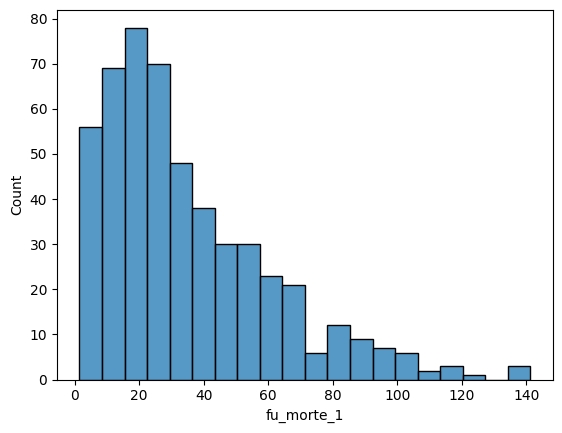

In [3]:
import seaborn as sns
import math

sns.histplot(data=train.query('Death_preHD==1'), x="fu_morte_1", bins=20)

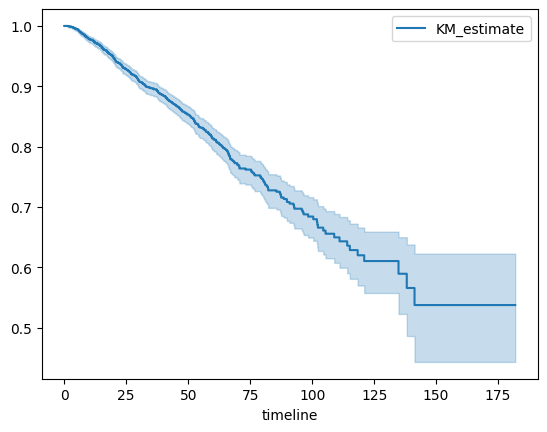

In [4]:
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# Visualize the survival distribution
kmf = KaplanMeierFitter()
kmf.fit(durations=train['fu_morte_1'], event_observed=train['Death_preHD'])
kmf.plot_survival_function()
plt.show()

### Feature selection using permutation based feature importance

In [5]:
import numpy as np
from sklearn.model_selection import KFold
import lifelines
from sklearn.inspection import permutation_importance
from sksurv.ensemble import RandomSurvivalForest

# SHAP value based feature selection 5 times, with 5 different random states

n_splits = 5
random_states = [1, 25, 100, 55, 30]

X = train.drop(columns=['fu_morte_1', 'Death_preHD'])
y = np.array([(bool(event), time) for event, time in zip(train['Death_preHD'], train['fu_morte_1'])],
             dtype=[('mortality', bool), ('fu_morte_1', float)])

feat_importance_dfs = []

for random_state in random_states:
    print('-----------------\nrandom state: ' + str(random_state) + ' \n')
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    c_indices = []
    
    for i, (train_idx, test_idx) in enumerate(kf.split(train)):
        
        train_fold = train.iloc[train_idx]
        test_fold = train.iloc[test_idx]

        X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
        y_train_fold, y_test_fold = y[train_idx], y[test_idx]
        model_feature_select = RandomSurvivalForest(n_estimators = 50, 
                                                    max_depth = 5, 
                                                    min_samples_split = 3, 
                                                    min_samples_leaf = 3, 
                                                    random_state=1)
        model_feature_select.fit(X_train_fold, y_train_fold)
        
        feat_import = permutation_importance(model_feature_select, X_test_fold, y_test_fold)
        
        feat_importance_dfs.append(pd.DataFrame(
                {
                    k: feat_import[k]
                    for k in (
                        "importances_mean",
                    )
                },
                index=test_fold.drop(columns=['fu_morte_1', 'Death_preHD']).columns,
            ))
            
        # Calculate the c-index in test_fold
        pred = model_feature_select.predict(X_test_fold)
        c_index = lifelines.utils.concordance_index(test_fold['fu_morte_1'], -pred, test_fold['Death_preHD'])
        c_indices.append(c_index)
        # Print progress
        print('Iter ' + str(i+1))
        print('C-index: ' + str(round(c_index, 2)) + '\n')
        
    print('The C index with all variables is: '+ str(round(np.mean(c_indices), 2)) + '±' + str(round(np.std(c_indices), 2)) + '\n\n')


-----------------
random state: 1 

Iter 1
C-index: 0.75

Iter 2
C-index: 0.73

Iter 3
C-index: 0.69

Iter 4
C-index: 0.76

Iter 5
C-index: 0.74

The C index with all variables is: 0.73±0.02


-----------------
random state: 25 

Iter 1
C-index: 0.73

Iter 2
C-index: 0.73

Iter 3
C-index: 0.73

Iter 4
C-index: 0.72

Iter 5
C-index: 0.75

The C index with all variables is: 0.73±0.01


-----------------
random state: 100 

Iter 1
C-index: 0.75

Iter 2
C-index: 0.75

Iter 3
C-index: 0.75

Iter 4
C-index: 0.7

Iter 5
C-index: 0.72

The C index with all variables is: 0.73±0.02


-----------------
random state: 55 

Iter 1
C-index: 0.72

Iter 2
C-index: 0.75

Iter 3
C-index: 0.77

Iter 4
C-index: 0.74

Iter 5
C-index: 0.7

The C index with all variables is: 0.74±0.02


-----------------
random state: 30 

Iter 1
C-index: 0.76

Iter 2
C-index: 0.68

Iter 3
C-index: 0.76

Iter 4
C-index: 0.74

Iter 5
C-index: 0.78

The C index with all variables is: 0.74±0.03




In [6]:
feat_importance_df = pd.concat(feat_importance_dfs, axis=1)
feat_importance_df['mean'] = feat_importance_df.mean(axis=1).round(3)
feat_importance_df = feat_importance_df[['mean']]

In [7]:
feature_dict = {'Eta1': 'Age',
                'Sesso': 'Sex',
                'Diabete': 'Diabetes',
                'Prot1': 'Proteinuria',
                'Epi1': 'eGFR',
                'Colesterolo1': 'Cholesterol',
                'Hb1': 'Hemoglobin',
                'Ca1': 'Calcium',
                'P1': 'Phosphorus',
                'BMI1': 'BMI',
                'ckd_cause_hypertens': 'CKD cause: hypertension',
                'ckd_cause_diabet': 'CKD cause: diabetes',
                'ckd_cause_glom_dis': 'CKD cause: glomerular disease',
                'ckd_cause_tubul_inter': 'CKD cause: tubulointerstitial disease',
                'ckd_cause_pkd': 'CKD cause: ADPKD'
               }

df_feature_dict = pd.DataFrame({'feat_name_in_df': list(feature_dict.keys()), 'feat_name': list(feature_dict.values())})
df_feature_dict.index = list(df_feature_dict['feat_name_in_df'])
df_feature_dict = df_feature_dict[['feat_name']]
feat_importance_df_disp = df_feature_dict.join(feat_importance_df)
feat_importance_df_disp = feat_importance_df_disp.sort_values(by = 'mean', ascending = False)

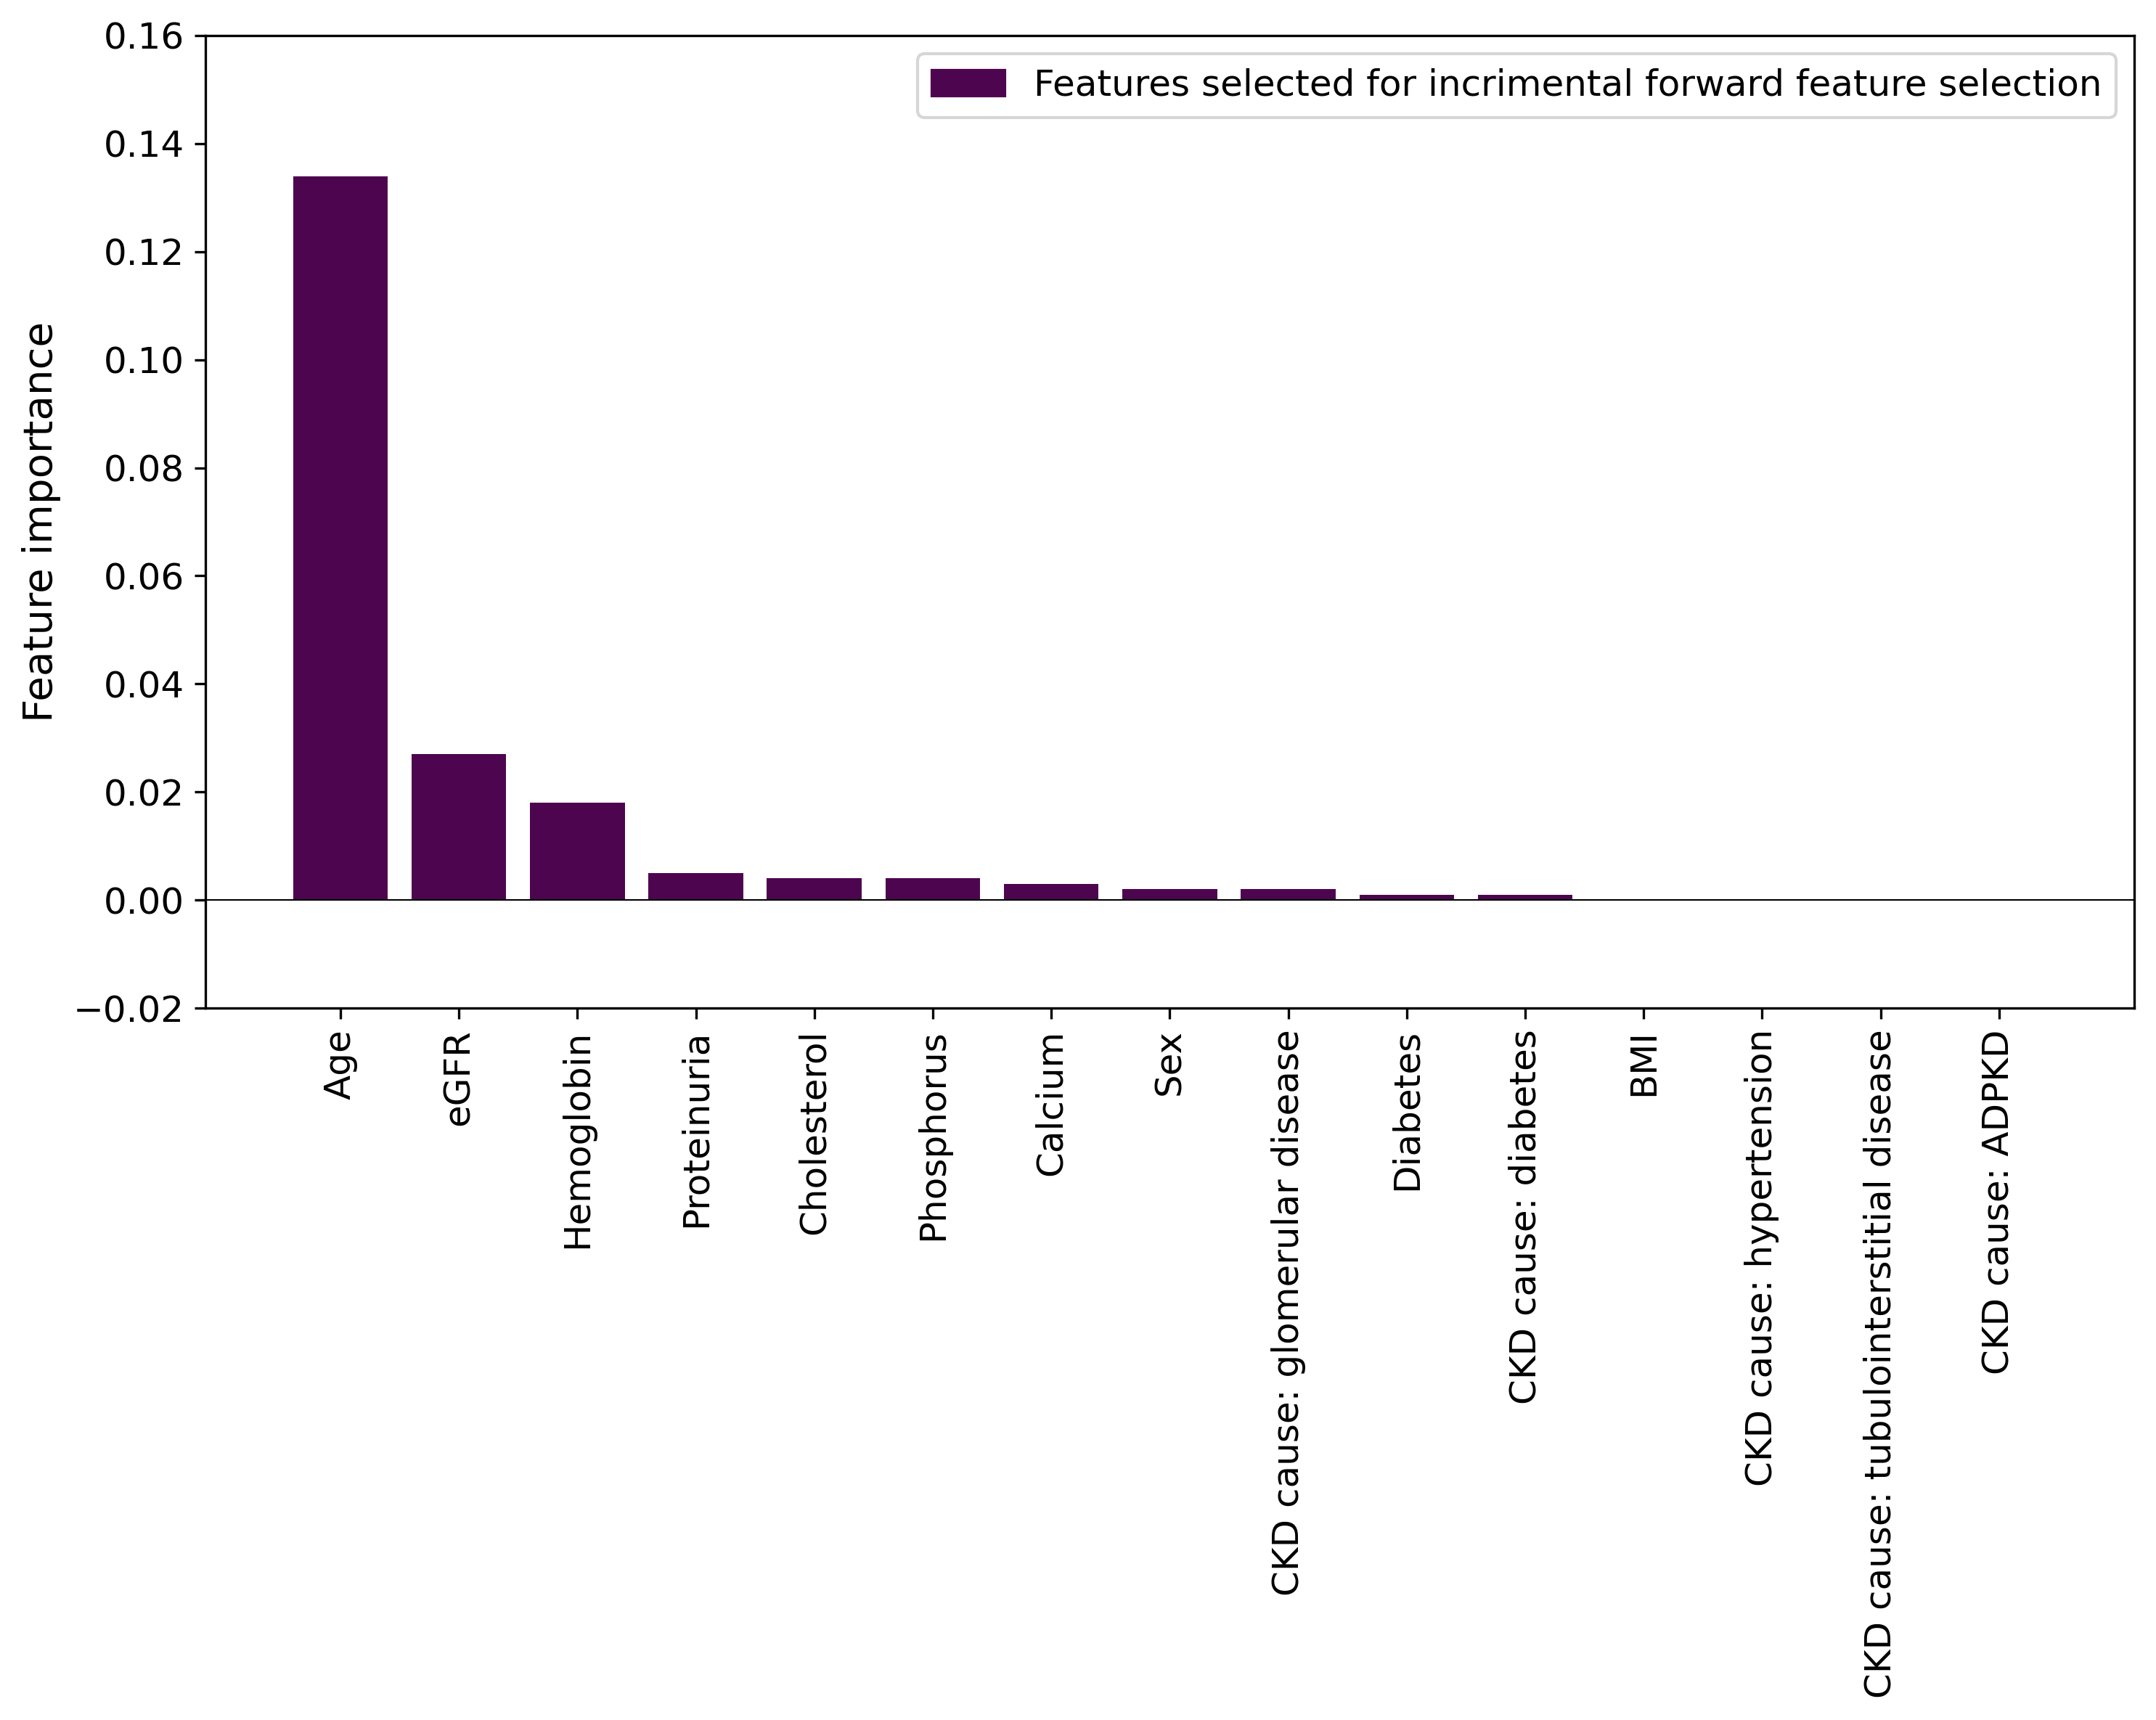

In [8]:
from matplotlib.pyplot import figure
from matplotlib.patches import Patch

colors = ['xkcd:plum purple' if val > 0.0 else 'gray' for val in feat_importance_df_disp['mean']]
figure(figsize=(10, 8), dpi = 300)
plt.bar(feat_importance_df_disp['feat_name'], feat_importance_df_disp['mean'], color = colors)
plt.yticks([-0.02, 0.00, 0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.14, 0.16], fontsize = 12)
plt.xticks(rotation=90, fontsize = 12)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.ylabel('Feature importance', fontsize = 13.5)
patch = Patch(color='xkcd:plum purple', label='Features selected for incrimental forward feature selection')
plt.legend(ncols = 2,handles=[patch], loc='upper right', fontsize = 12)
plt.tight_layout()
plt.savefig("figures/supplemental_figure_3.pdf")
plt.show()

In [9]:
features_feat_select = [feat_importance_df_disp.index[i] for i, val in enumerate(feat_importance_df_disp['mean']) if val > 0.0 ]
features_feat_select

['Eta1',
 'Epi1',
 'Hb1',
 'Prot1',
 'Colesterolo1',
 'P1',
 'Ca1',
 'Sesso',
 'ckd_cause_glom_dis',
 'Diabete',
 'ckd_cause_diabet']

In [10]:
from sklearn.model_selection import GridSearchCV

var_dict = {'feat' : [],
            'c_index': [],
            'sd': [],
            'best_hyperparams': [],
            'df_result': [],
            'param_combinations': []}

param_grid = {
    'n_estimators': [50, 75, 100],
    'max_depth': [3, 5, 8],
    'min_samples_split': [3, 10, 15],
    'min_samples_leaf': [3, 10, 15],
    'max_features': ['sqrt', 'log2', None]
}

def c_index_scorer(model, X, y):
    risk_scores = model.predict(X)
    return lifelines.utils.concordance_index(
        event_times=y['fu_morte_1'],
        predicted_scores=-risk_scores,
        event_observed=y['Death_preHD']
    )

for i, feature in enumerate(features_feat_select):
    
    features_to_train_current_iter = features_feat_select[:(i+1)]
    features_to_train_current_iter.extend(['fu_morte_1', 'Death_preHD'])

    train_current_iter = train[features_to_train_current_iter]

    X = train_current_iter.drop(columns=['fu_morte_1', 'Death_preHD'])
    y = np.array([(bool(event), time) for event, time in zip(train_current_iter['Death_preHD'], train_current_iter['fu_morte_1'])],
             dtype=[('Death_preHD', bool), ('fu_morte_1', float)])

    rsf = RandomSurvivalForest(random_state=1)
    cv = KFold(n_splits=5, shuffle=True, random_state=1)
    
    grid_search = GridSearchCV(
        estimator=rsf,
        param_grid=param_grid,
        cv=cv,
        scoring=c_index_scorer
    )
    
    grid_search.fit(X, y)
        
    var_dict['feat'].append(feature)
    var_dict['c_index'].append(grid_search.best_score_)
    var_dict['best_hyperparams'].append(grid_search.best_params_)
    print('')
    print('----------\nModel with adding feature ' + feature + ' has a c index of ' + str(round(grid_search.best_score_, 3)))
    print('Best params: ' + str(grid_search.best_params_))
    print('progress: ' + str(i+1) + ' out of ' + str(len(features_feat_select)) + '\n\n')


----------
Model with adding feature Eta1 has a c index of 0.716
Best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'min_samples_split': 3, 'n_estimators': 50}
progress: 1 out of 11



----------
Model with adding feature Epi1 has a c index of 0.728
Best params: {'max_depth': 3, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 3, 'n_estimators': 75}
progress: 2 out of 11



----------
Model with adding feature Hb1 has a c index of 0.732
Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 75}
progress: 3 out of 11



----------
Model with adding feature Prot1 has a c index of 0.741
Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 3, 'n_estimators': 50}
progress: 4 out of 11



----------
Model with adding feature Colesterolo1 has a c index of 0.743
Best params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'mi

In [15]:
if True:
    import json
    with open('raw_results/feature_selection_results_secondary_outcome.json', 'w') as f:
        f.write(json.dumps(var_dict))

In [12]:
df_feat_import = pd.DataFrame({'feat': var_dict['feat'], 'c_index': var_dict['c_index']})
feat_names = list()
for var in var_dict['feat']:
    feat_names.append(feature_dict[var])
df_feature_dict = pd.DataFrame({'feat_name_in_df': var_dict['feat'], 'feat_name': feat_names})
df_feature_dict

,feat_name_in_df,feat_name
0,Eta1,Age
1,Epi1,eGFR
2,Hb1,Hemoglobin
3,Prot1,Proteinuria
4,Colesterolo1,Cholesterol
5,P1,Phosphorus
6,Ca1,Calcium
7,Sesso,Sex
8,ckd_cause_glom_dis,CKD cause: glomerular disease
9,Diabete,Diabetes


In [13]:
df_feat_import['c_index'] = df_feat_import['c_index'].round(3)

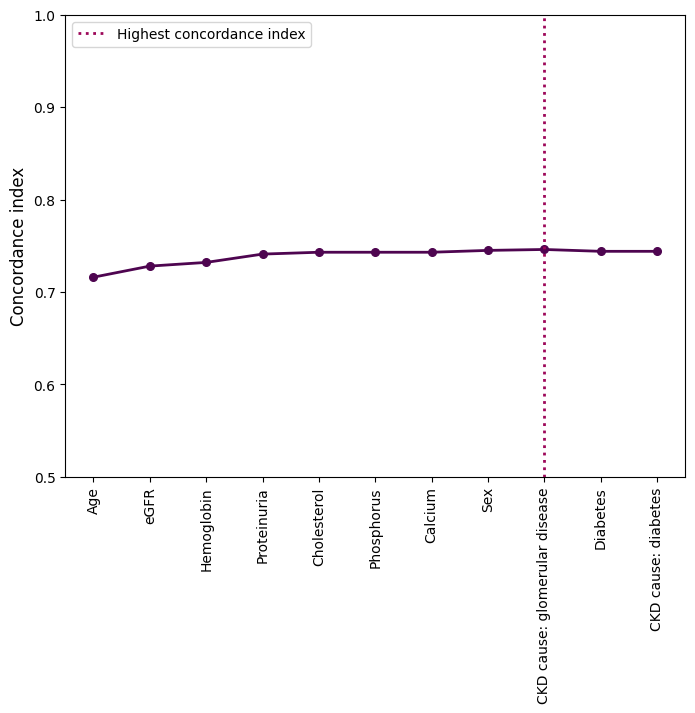

In [14]:
plt.figure(figsize=(8, 6))
plt.plot(feat_names, df_feat_import['c_index'], marker = 'o', markersize = 5.5, color = 'xkcd:plum purple', linewidth = 2.0)
plt.xticks(rotation=90, fontsize = 10)
plt.yticks(fontsize = 10)
plt.ylabel('Concordance index', fontsize = 12)
plt.ylim(0.5, 1.0)
plt.axvline(x=np.argmax(df_feat_import['c_index']), color='xkcd:dark fuchsia', linestyle='dotted', linewidth = 2.0, label = 'Highest concordance index')
plt.legend()
plt.savefig("figures/supplemental_figure_4.pdf", bbox_inches='tight')

plt.show()